# Projeto em Ciência de Dados — Grupo 4
## Notebook 2.0 — Modelação e Treino
**Afonso Carvalho & Marcello Portugal** | ISCAC

In [1]:
# Afonso Carvalho e Marcello Portugal
# Importacoes

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, learning_curve,
    RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

## 1. Carregamento dos Dados

In [2]:
# Afonso Carvalho e Marcello Portugal
# Carregar o dataset final da M2 (com capping e feature engineering aplicados)

kaggle_path = '/kaggle/input/datasets/marcelloportugal/dataset-final-para-modelacao/wine_quality_model_final (1).csv'
local_path  = '../data/processed/wine_quality_model_final.csv'

data_path = kaggle_path if os.path.exists(kaggle_path) else local_path
df = pd.read_csv(data_path)

print(f'Dataset carregado: {df.shape[0]} registos x {df.shape[1]} colunas')
print(df.columns.tolist())

Dataset carregado: 6497 registos x 13 colunas
['fixed acidity', 'citric acid', 'residual sugar', 'chlorides', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'is_red', 'so2_ratio', 'volatile_acidity_ratio']


In [3]:
# Afonso Carvalho e Marcello Portugal
# Inspecao rapida e verificacao de valores nulos

print('Nulos por coluna:')
print(df.isnull().sum())
df.head(5)

Nulos por coluna:
fixed acidity             0
citric acid               0
residual sugar            0
chlorides                 0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                   0
is_red                    0
so2_ratio                 0
volatile_acidity_ratio    0
dtype: int64


,fixed acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,density,pH,sulphates,alcohol,quality,is_red,so2_ratio,volatile_acidity_ratio
0,7.40,0.04,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,5,1,0.323529,0.088514
1,7.80,0.04,2.6,0.098,67.0,0.9968,3.20,0.68,9.8,5,1,0.373134,0.083974
2,7.80,0.04,2.3,0.092,54.0,0.9970,3.26,0.65,9.8,5,1,0.277778,0.083974
3,9.65,0.56,1.9,0.075,60.0,0.9980,3.16,0.58,9.8,6,1,0.283333,0.029016
4,7.40,0.04,1.9,0.076,34.0,0.9978,3.51,0.56,9.4,5,1,0.323529,0.088514


## 2. Separacao de Features e Variavel Alvo

In [4]:
# Afonso Carvalho e Marcello Portugal
# X = variaveis preditoras | y = qualidade (variavel alvo)

TARGET = 'quality'

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f'Features: {X.shape[1]} variaveis')
print(f'Alvo: "{TARGET}" | Distribuicao: {dict(y.value_counts().sort_index())}')

Features: 12 variaveis
Alvo: "quality" | Distribuicao: {3: np.int64(30), 4: np.int64(216), 5: np.int64(2138), 6: np.int64(2836), 7: np.int64(1079), 8: np.int64(193), 9: np.int64(5)}


## 3. Divisao Treino / Teste (Aula 15)
Divisao 80/20 com semente fixa para garantir reprodutibilidade.

In [5]:
# Afonso Carvalho e Marcello Portugal
# Divisao Hold-Out 80/20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Treino : {X_train.shape[0]} registos ({X_train.shape[0]/len(df)*100:.1f}%)')
print(f'Teste  : {X_test.shape[0]}  registos ({X_test.shape[0]/len(df)*100:.1f}%)')

Treino : 5197 registos (80.0%)
Teste  : 1300  registos (20.0%)


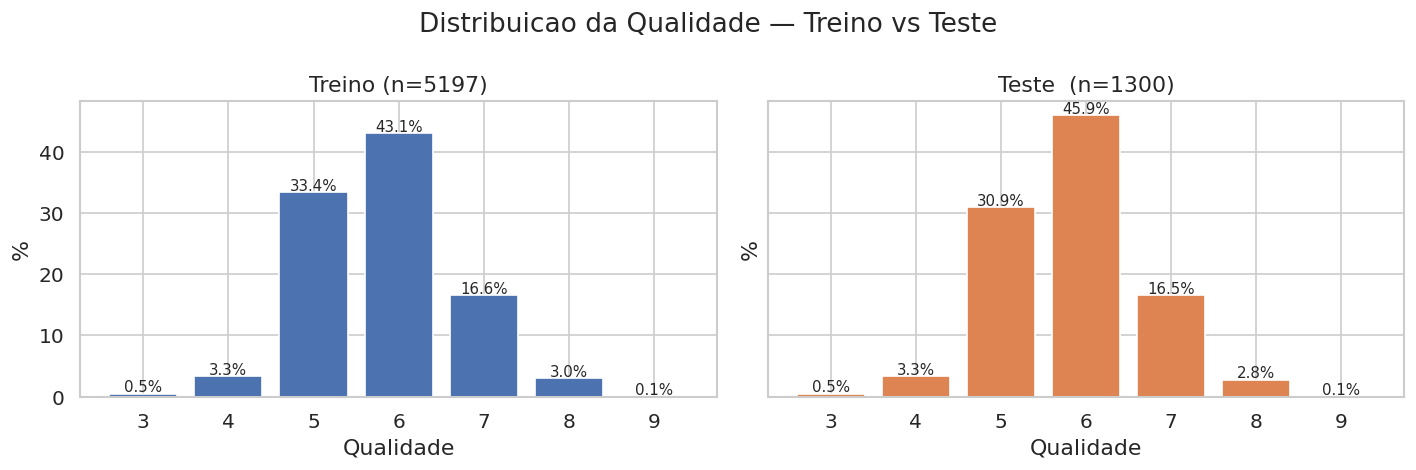

In [6]:
# Afonso Carvalho e Marcello Portugal
# Verificar se a distribuicao de 'quality' e semelhante em treino e teste

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (data, title, color) in zip(
    axes,
    [(y_train, f'Treino (n={len(y_train)})', '#4C72B0'),
     (y_test,  f'Teste  (n={len(y_test)})',  '#DD8452')]
):
    counts = data.value_counts().sort_index()
    pct    = counts / len(data) * 100
    ax.bar(counts.index, pct, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Qualidade')
    ax.set_ylabel('%')
    for v, p in zip(counts.index, pct):
        ax.text(v, p + 0.3, f'{p:.1f}%', ha='center', fontsize=9)

plt.suptitle('Distribuicao da Qualidade — Treino vs Teste')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/M3_split_distribuicao.png', bbox_inches='tight')
plt.show()

## 4. Normalizacao dos Dados
O StandardScaler e ajustado apenas no treino para evitar fuga de informacao (*data leakage*).

In [7]:
# Afonso Carvalho e Marcello Portugal
# StandardScaler: fit apenas no treino, transform em ambos

scaler = StandardScaler()

X_train_sc = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_sc = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

print('Normalizacao aplicada.')
print(f'Media de alcohol no treino: {scaler.mean_[X_train.columns.get_loc("alcohol")]:.4f}')

Normalizacao aplicada.
Media de alcohol no treino: 10.4836


## 5. Metricas de Avaliacao (Aula 15)
Problema de regressao — metricas escolhidas: MAE (principal), RMSE e R².

In [8]:
# Afonso Carvalho e Marcello Portugal
# Funcao de avaliacao: calcula MAE, RMSE e R2 para treino e teste

def avaliar_modelo(nome, y_treino, y_treino_pred, y_teste, y_teste_pred):
    return {
        'Modelo'       : nome,
        'MAE Treino'   : round(mean_absolute_error(y_treino, y_treino_pred), 4),
        'RMSE Treino'  : round(np.sqrt(mean_squared_error(y_treino, y_treino_pred)), 4),
        'R2 Treino'    : round(r2_score(y_treino, y_treino_pred), 4),
        'MAE Teste'    : round(mean_absolute_error(y_teste, y_teste_pred), 4),
        'RMSE Teste'   : round(np.sqrt(mean_squared_error(y_teste, y_teste_pred)), 4),
        'R2 Teste'     : round(r2_score(y_teste, y_teste_pred), 4),
    }

todos_resultados = []
print('Funcao de avaliacao definida. Objetivo: MAE < 0.5 no teste.')

Funcao de avaliacao definida. Objetivo: MAE < 0.5 no teste.


## 6. Modelos Baseline (Aula 16)

In [9]:
# Afonso Carvalho e Marcello Portugal
# B1: DummyRegressor — preve sempre a media do treino (pior caso razoavel)

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_sc, y_train)

res_dummy = avaliar_modelo(
    'B1 - Previsao pela Media',
    y_train, dummy.predict(X_train_sc),
    y_test,  dummy.predict(X_test_sc)
)
todos_resultados.append(res_dummy)

print('B1 — Previsao pela Media')
for k, v in res_dummy.items():
    print(f'  {k}: {v}')

B1 — Previsao pela Media
  Modelo: B1 - Previsao pela Media
  MAE Treino: 0.691
  RMSE Treino: 0.8766
  R2 Treino: 0.0
  MAE Teste: 0.6691
  RMSE Teste: 0.8596
  R2 Teste: -0.0005


In [10]:
# Afonso Carvalho e Marcello Portugal
# B2: Regressao Linear — modelo mais simples que usa de facto as variaveis

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

res_lr = avaliar_modelo(
    'B2 - Regressao Linear',
    y_train, lr.predict(X_train_sc),
    y_test,  lr.predict(X_test_sc)
)
todos_resultados.append(res_lr)

print('B2 — Regressao Linear')
for k, v in res_lr.items():
    print(f'  {k}: {v}')

B2 — Regressao Linear
  Modelo: B2 - Regressao Linear
  MAE Treino: 0.5659
  RMSE Treino: 0.7314
  R2 Treino: 0.3038
  MAE Teste: 0.5607
  RMSE Teste: 0.7285
  R2 Teste: 0.2814


In [11]:
# Afonso Carvalho e Marcello Portugal
# Coeficientes da regressao linear (ordenados por impacto absoluto)

coefs = pd.Series(lr.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print('Coeficientes:')
print(coefs.round(4).to_string())

Coeficientes:
alcohol                   0.3023
residual sugar            0.2476
volatile_acidity_ratio   -0.2328
density                  -0.2323
sulphates                 0.1202
is_red                    0.1165
so2_ratio                 0.0936
pH                        0.0526
chlorides                -0.0317
fixed acidity            -0.0164
citric acid               0.0058
total sulfur dioxide     -0.0014


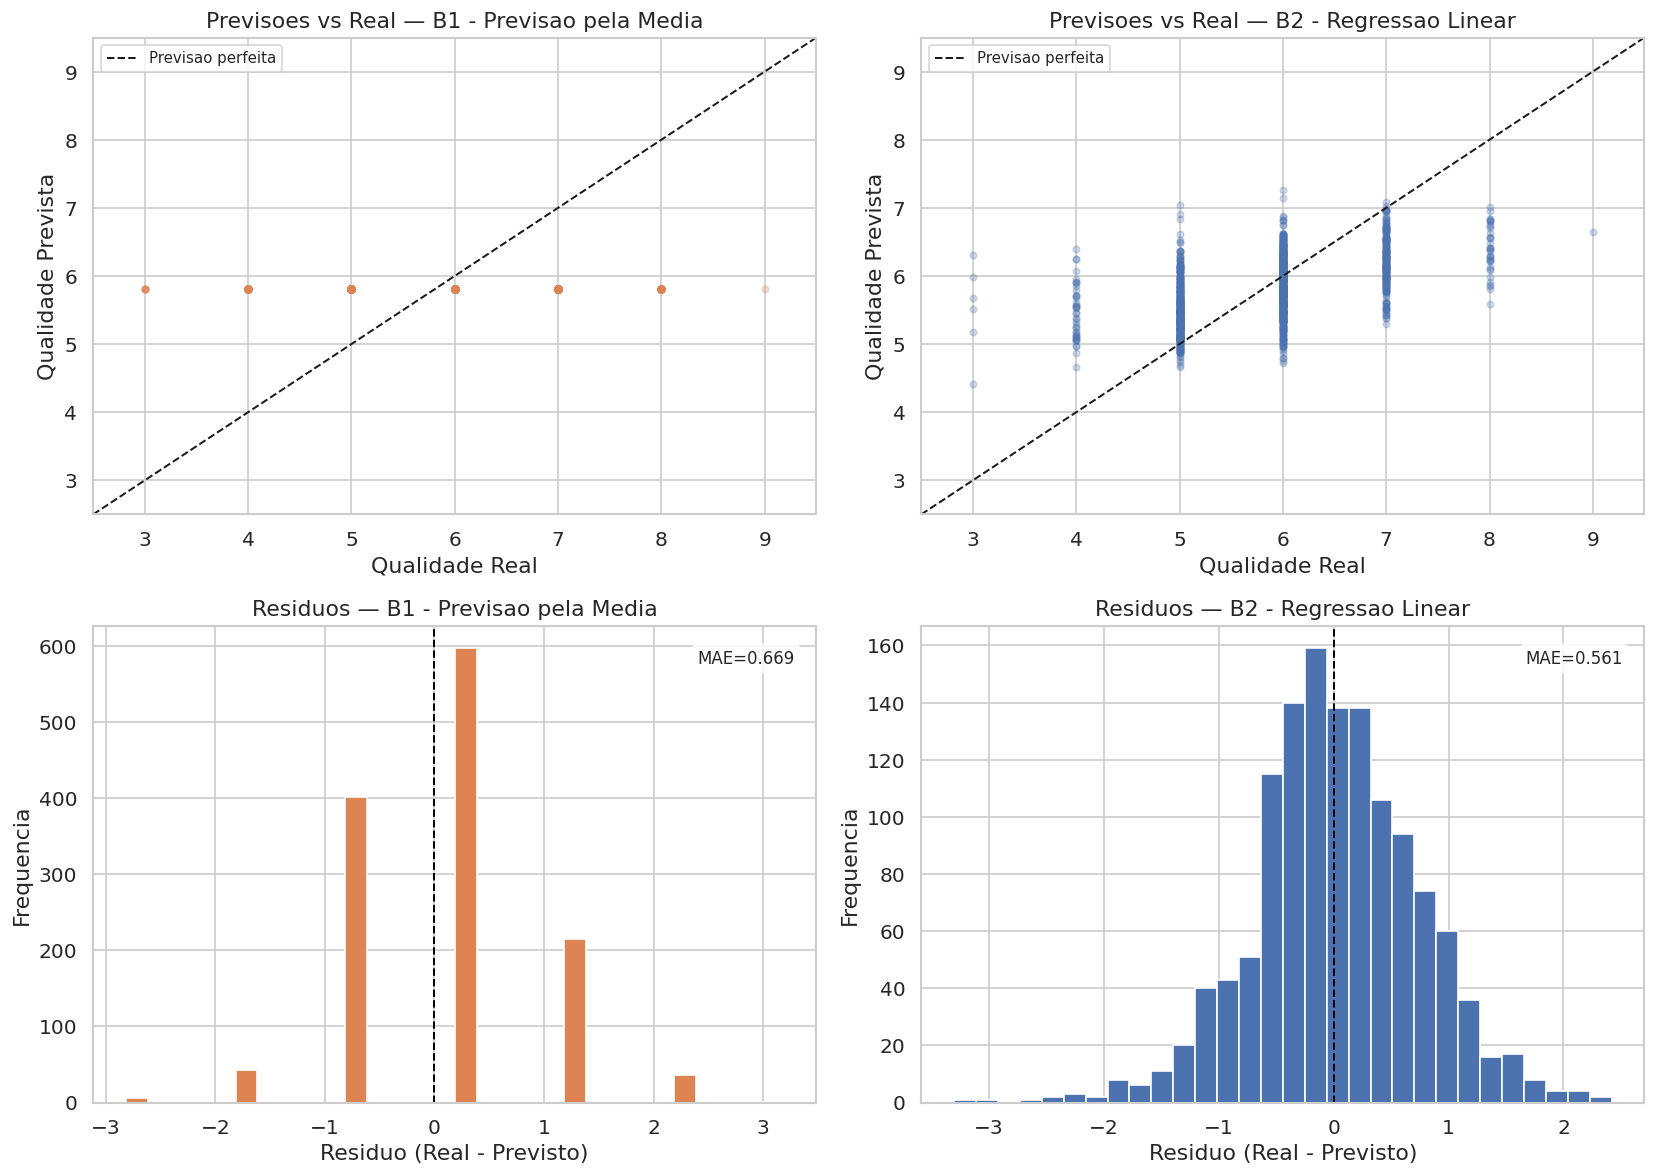

In [12]:
# Afonso Carvalho e Marcello Portugal
# Graficos baseline: previsoes vs valores reais e residuos

y_dummy_te = dummy.predict(X_test_sc)
y_lr_te    = lr.predict(X_test_sc)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (y_pred, titulo, cor) in enumerate([
    (y_dummy_te, 'B1 - Previsao pela Media', '#DD8452'),
    (y_lr_te,    'B2 - Regressao Linear',    '#4C72B0')
]):
    ax = axes[0, i]
    ax.scatter(y_test, y_pred, alpha=0.25, s=15, color=cor)
    lims = [y_test.min() - 0.5, y_test.max() + 0.5]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Previsao perfeita')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Qualidade Real'); ax.set_ylabel('Qualidade Prevista')
    ax.set_title(f'Previsoes vs Real — {titulo}')
    ax.legend(fontsize=9)

    ax = axes[1, i]
    residuos = y_test - y_pred
    ax.hist(residuos, bins=30, color=cor, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xlabel('Residuo (Real - Previsto)'); ax.set_ylabel('Frequencia')
    ax.set_title(f'Residuos — {titulo}')
    ax.text(0.97, 0.95, f'MAE={mean_absolute_error(y_test, y_pred):.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../reports/figures/M3_baseline_graficos.png', bbox_inches='tight')
plt.show()

In [13]:
# Afonso Carvalho e Marcello Portugal
# Guardar resultados baseline

df_baseline = pd.DataFrame(todos_resultados).set_index('Modelo')
display(df_baseline.style.format('{:.4f}'))

os.makedirs('../reports', exist_ok=True)
df_baseline.to_csv('../reports/M3_resultados_baseline.csv')
print('Baseline guardado. Objetivo: MAE Teste < 0.5')
print(f'Melhor baseline (B2): MAE Teste = {res_lr["MAE Teste"]}')

,MAE Treino,RMSE Treino,R2 Treino,MAE Teste,RMSE Teste,R2 Teste
Modelo,,,,,,
B1 - Previsao pela Media,0.6910,0.8766,0.0000,0.6691,0.8596,-0.0005
B2 - Regressao Linear,0.5659,0.7314,0.3038,0.5607,0.7285,0.2814


Baseline guardado. Objetivo: MAE Teste < 0.5
Melhor baseline (B2): MAE Teste = 0.5607


## 7. Modelos Candidatos (Aula 17)

In [14]:
# Afonso Carvalho e Marcello Portugal
# Random Forest — parametros base

rf = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf.fit(X_train_sc, y_train)

res_rf = avaliar_modelo(
    'Random Forest',
    y_train, rf.predict(X_train_sc),
    y_test,  rf.predict(X_test_sc)
)
todos_resultados.append(res_rf)

print('Random Forest')
for k, v in res_rf.items():
    print(f'  {k}: {v}')

Random Forest
  Modelo: Random Forest
  MAE Treino: 0.1608
  RMSE Treino: 0.2283
  R2 Treino: 0.9322
  MAE Teste: 0.4408
  RMSE Teste: 0.6136
  R2 Teste: 0.4902


In [15]:
# Afonso Carvalho e Marcello Portugal
# Random Forest — ajuste inicial de hiperparametros
# Testou-se adicionar restricoes de profundidade para reduzir o overfitting observado

rf_aj = RandomForestRegressor(
    n_estimators=300, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    random_state=SEED, n_jobs=-1
)
rf_aj.fit(X_train_sc, y_train)

mae_rf_aj = mean_absolute_error(y_test, rf_aj.predict(X_test_sc))
print(f'Random Forest ajustado — MAE Teste: {mae_rf_aj:.4f}')
print(f'Random Forest base     — MAE Teste: {res_rf["MAE Teste"]}')
print('Conclusao: parametros base sao superiores; manter configuracao original.')

Random Forest ajustado — MAE Teste: 0.4651
Random Forest base     — MAE Teste: 0.4408
Conclusao: parametros base sao superiores; manter configuracao original.


In [16]:
# Afonso Carvalho e Marcello Portugal
# XGBoost — parametros base

xgb = XGBRegressor(random_state=SEED, verbosity=0)
xgb.fit(X_train_sc, y_train)

res_xgb = avaliar_modelo(
    'XGBoost',
    y_train, xgb.predict(X_train_sc),
    y_test,  xgb.predict(X_test_sc)
)
todos_resultados.append(res_xgb)

print('XGBoost')
for k, v in res_xgb.items():
    print(f'  {k}: {v}')

XGBoost
  Modelo: XGBoost
  MAE Treino: 0.1835
  RMSE Treino: 0.257
  R2 Treino: 0.914
  MAE Teste: 0.4673
  RMSE Teste: 0.6397
  R2 Teste: 0.446


In [17]:
# Afonso Carvalho e Marcello Portugal
# XGBoost — ajuste inicial: aprendizagem mais lenta com mais arvores e subamostragem

xgb_aj = XGBRegressor(
    n_estimators=300, max_depth=5,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED, verbosity=0
)
xgb_aj.fit(X_train_sc, y_train)

mae_xgb_aj = mean_absolute_error(y_test, xgb_aj.predict(X_test_sc))
print(f'XGBoost ajustado — MAE Teste: {mae_xgb_aj:.4f}')
print(f'XGBoost base     — MAE Teste: {res_xgb["MAE Teste"]}')
print('Conclusao: resultados semelhantes; manter configuracao base.')

XGBoost ajustado — MAE Teste: 0.4929
XGBoost base     — MAE Teste: 0.4673
Conclusao: resultados semelhantes; manter configuracao base.


In [18]:
# Afonso Carvalho e Marcello Portugal
# SVR — ajuste do parametro C
# C controla o equilibrio entre margem e erros de treino

svr_c1  = SVR(kernel='rbf', C=1.0,  epsilon=0.1)
svr_c10 = SVR(kernel='rbf', C=10.0, epsilon=0.05)

svr_c1.fit(X_train_sc, y_train)
svr_c10.fit(X_train_sc, y_train)

print(f'SVR C=1  — MAE Teste: {mean_absolute_error(y_test, svr_c1.predict(X_test_sc)):.4f}')
print(f'SVR C=10 — MAE Teste: {mean_absolute_error(y_test, svr_c10.predict(X_test_sc)):.4f}')

# Usar C=10 como configuracao final
res_svr = avaliar_modelo(
    'SVR (C=10)',
    y_train, svr_c10.predict(X_train_sc),
    y_test,  svr_c10.predict(X_test_sc)
)
todos_resultados.append(res_svr)

print('\nSVR (C=10)')
for k, v in res_svr.items():
    print(f'  {k}: {v}')

SVR C=1  — MAE Teste: 0.5101
SVR C=10 — MAE Teste: 0.5061

SVR (C=10)
  Modelo: SVR (C=10)
  MAE Treino: 0.3756
  RMSE Treino: 0.5656
  R2 Treino: 0.5837
  MAE Teste: 0.5061
  RMSE Teste: 0.6778
  R2 Teste: 0.3779


In [19]:
# Afonso Carvalho e Marcello Portugal
# Tabela comparativa de todos os modelos

df_todos = pd.DataFrame(todos_resultados).set_index('Modelo')
display(df_todos.style
    .format('{:.4f}')
    .highlight_min(subset=['MAE Teste', 'RMSE Teste'], color='#d4edda')
    .highlight_max(subset=['R2 Teste'], color='#d4edda')
)

df_todos.to_csv('../reports/M3_resultados_todos.csv')
print('Tabela guardada.')

,MAE Treino,RMSE Treino,R2 Treino,MAE Teste,RMSE Teste,R2 Teste
Modelo,,,,,,
B1 - Previsao pela Media,0.6910,0.8766,0.0000,0.6691,0.8596,-0.0005
B2 - Regressao Linear,0.5659,0.7314,0.3038,0.5607,0.7285,0.2814
Random Forest,0.1608,0.2283,0.9322,0.4408,0.6136,0.4902
XGBoost,0.1835,0.2570,0.9140,0.4673,0.6397,0.4460
SVR (C=10),0.3756,0.5656,0.5837,0.5061,0.6778,0.3779


Tabela guardada.


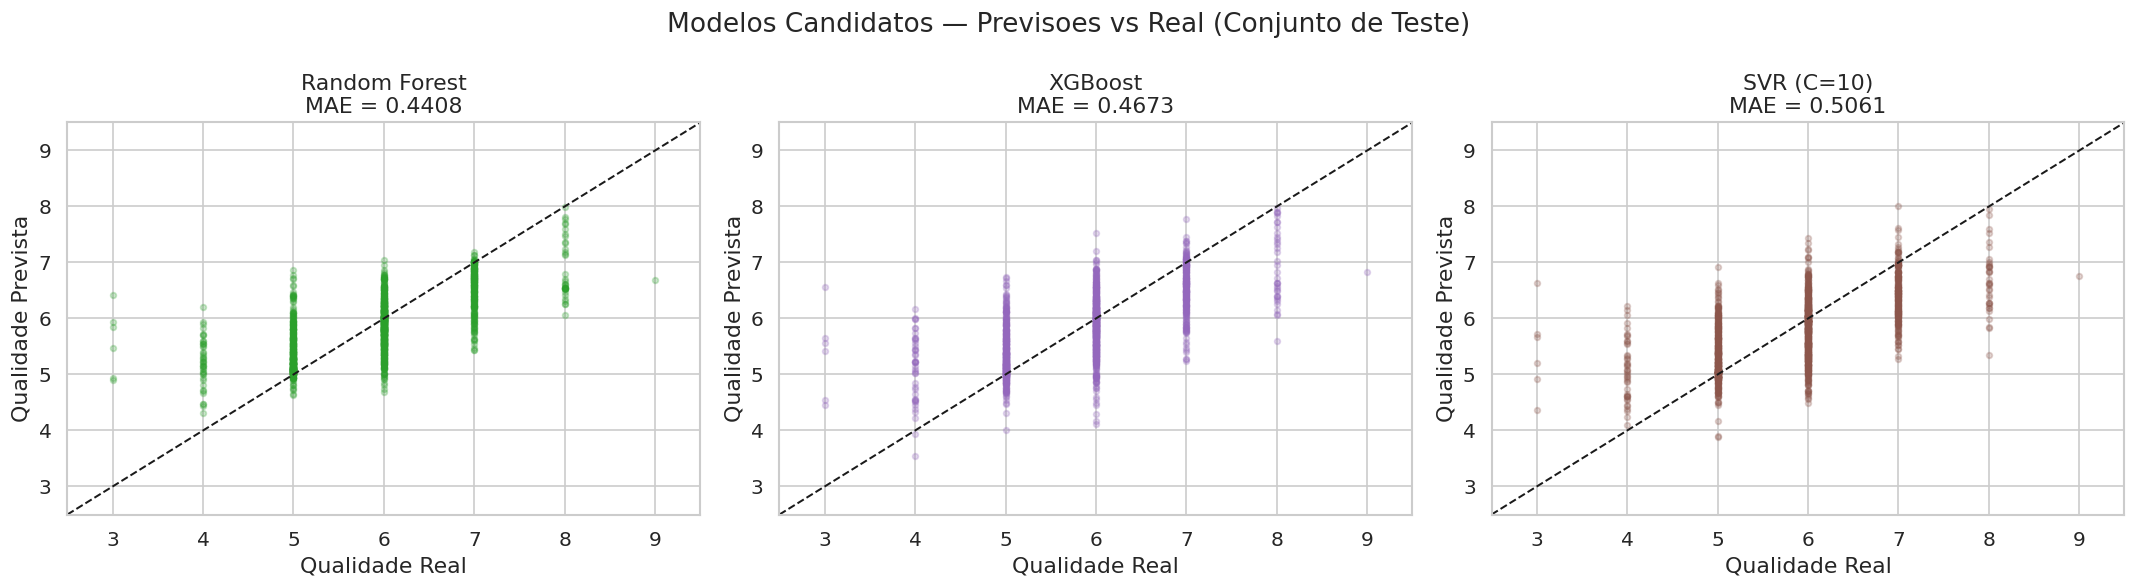

In [20]:
# Afonso Carvalho e Marcello Portugal
# Graficos comparativos: previsoes vs real para os tres modelos candidatos

candidatos = [
    (rf.predict(X_test_sc),      'Random Forest', '#2ca02c'),
    (xgb.predict(X_test_sc),     'XGBoost',       '#9467bd'),
    (svr_c10.predict(X_test_sc), 'SVR (C=10)',     '#8c564b'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lims = [y_test.min() - 0.5, y_test.max() + 0.5]

for ax, (y_pred, titulo, cor) in zip(axes, candidatos):
    ax.scatter(y_test, y_pred, alpha=0.25, s=12, color=cor)
    ax.plot(lims, lims, 'k--', linewidth=1.2)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Qualidade Real')
    ax.set_ylabel('Qualidade Prevista')
    mae_val = mean_absolute_error(y_test, y_pred)
    ax.set_title(f'{titulo}\nMAE = {mae_val:.4f}')

plt.suptitle('Modelos Candidatos — Previsoes vs Real (Conjunto de Teste)')
plt.tight_layout()
plt.savefig('../reports/figures/M3_candidatos_previsoes.png', bbox_inches='tight')
plt.show()

## 8. Diagnostico e Generalizacao (Aula 18)
Analise do sobreajuste (*overfitting*) e curvas de aprendizagem para o melhor modelo.

In [21]:
# Afonso Carvalho e Marcello Portugal
# Diagnostico: diferenca entre erro de treino e erro de teste para cada modelo

diagnostico = []
for r in todos_resultados:
    gap = round(r['MAE Teste'] - r['MAE Treino'], 4)
    if gap > 0.15:
        estado = 'Sobreajuste'
    elif gap < -0.05:
        estado = 'Subajuste'
    else:
        estado = 'Equilibrado'
    diagnostico.append({
        'Modelo'      : r['Modelo'],
        'MAE Treino'  : r['MAE Treino'],
        'MAE Teste'   : r['MAE Teste'],
        'Diferenca'   : gap,
        'Diagnostico' : estado
    })

df_diag = pd.DataFrame(diagnostico).set_index('Modelo')
display(df_diag)

,MAE Treino,MAE Teste,Diferenca,Diagnostico
Modelo,,,,
B1 - Previsao pela Media,0.6910,0.6691,-0.0219,Equilibrado
B2 - Regressao Linear,0.5659,0.5607,-0.0052,Equilibrado
Random Forest,0.1608,0.4408,0.2800,Sobreajuste
XGBoost,0.1835,0.4673,0.2838,Sobreajuste
SVR (C=10),0.3756,0.5061,0.1305,Equilibrado


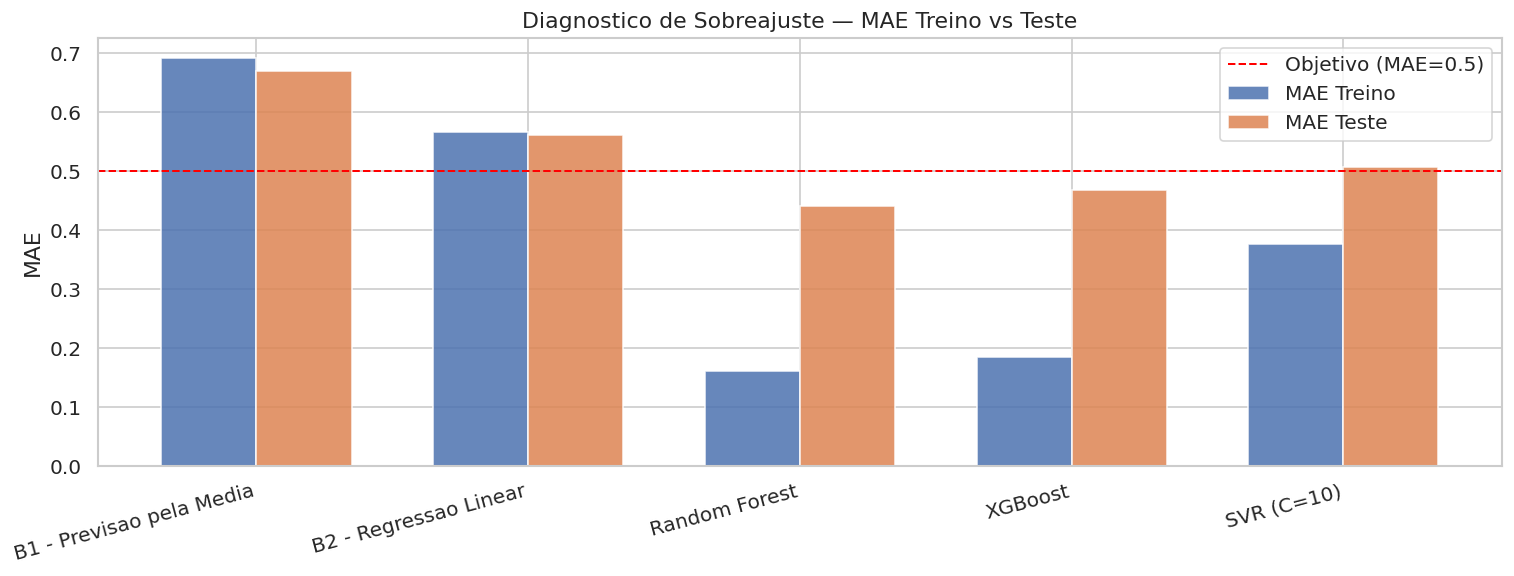

In [22]:
# Afonso Carvalho e Marcello Portugal
# Grafico de barras: MAE treino vs MAE teste para todos os modelos

modelos    = [r['Modelo'] for r in todos_resultados]
mae_treino = [r['MAE Treino'] for r in todos_resultados]
mae_teste  = [r['MAE Teste']  for r in todos_resultados]

x = np.arange(len(modelos))
w = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w/2, mae_treino, w, label='MAE Treino', color='#4C72B0', alpha=0.85)
ax.bar(x + w/2, mae_teste,  w, label='MAE Teste',  color='#DD8452', alpha=0.85)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Objetivo (MAE=0.5)')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=15, ha='right')
ax.set_ylabel('MAE')
ax.set_title('Diagnostico de Sobreajuste — MAE Treino vs Teste')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/M3_diagnostico_overfitting.png', bbox_inches='tight')
plt.show()

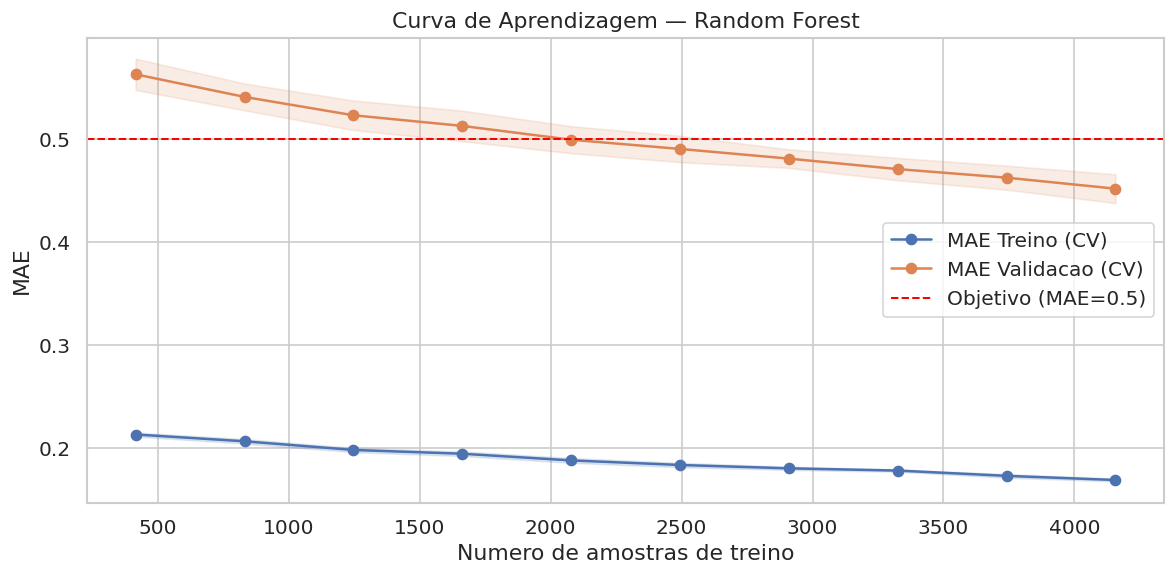

In [23]:
# Afonso Carvalho e Marcello Portugal
# Curva de aprendizagem — Random Forest (melhor modelo)
# Mostra como o erro evolui com o aumento do volume de dados de treino

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    X_train_sc, y_train,
    cv=5,
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mae = -train_scores.mean(axis=1)
val_mae   = -val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std   = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mae, 'o-', color='#4C72B0', label='MAE Treino (CV)')
ax.fill_between(train_sizes, train_mae - train_std, train_mae + train_std, alpha=0.15, color='#4C72B0')
ax.plot(train_sizes, val_mae, 'o-', color='#DD8452', label='MAE Validacao (CV)')
ax.fill_between(train_sizes, val_mae - val_std, val_mae + val_std, alpha=0.15, color='#DD8452')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Objetivo (MAE=0.5)')
ax.set_xlabel('Numero de amostras de treino')
ax.set_ylabel('MAE')
ax.set_title('Curva de Aprendizagem — Random Forest')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/M3_curva_aprendizagem_rf.png', bbox_inches='tight')
plt.show()

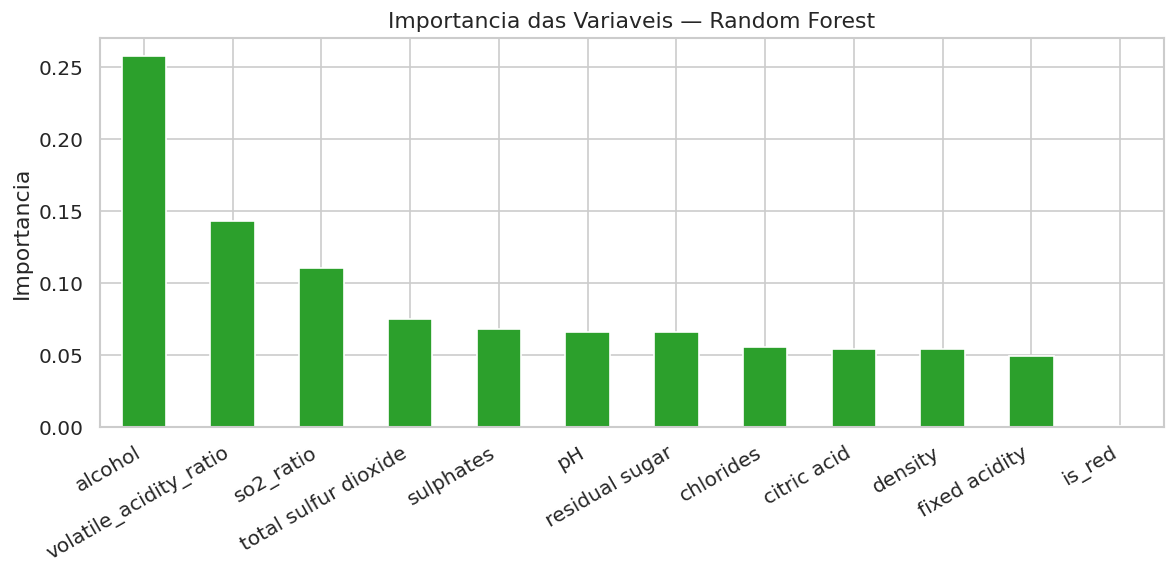

Importancia das variaveis:
alcohol                   0.2575
volatile_acidity_ratio    0.1431
so2_ratio                 0.1102
total sulfur dioxide      0.0748
sulphates                 0.0683
pH                        0.0661
residual sugar            0.0660
chlorides                 0.0554
citric acid               0.0545
density                   0.0540
fixed acidity             0.0495
is_red                    0.0006


In [24]:
# Afonso Carvalho e Marcello Portugal
# Importancia das variaveis — Random Forest

fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fi.plot(kind='bar', color='#2ca02c', edgecolor='white', ax=ax)
ax.set_title('Importancia das Variaveis — Random Forest')
ax.set_ylabel('Importancia')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/M3_feature_importance_rf.png', bbox_inches='tight')
plt.show()

print('Importancia das variaveis:')
print(fi.round(4).to_string())

In [25]:
# Afonso Carvalho e Marcello Portugal
# Selecao do modelo e resumo final

print('Resumo dos modelos candidatos (MAE Teste):')
print(df_todos[['MAE Treino', 'MAE Teste', 'R2 Teste']].sort_values('MAE Teste').to_string())
print()
print('Modelo selecionado: Random Forest (n_estimators=100)')
print(f'  MAE Teste = {res_rf["MAE Teste"]} < 0.5 — objetivo SMART alcancado')

Resumo dos modelos candidatos (MAE Teste):
                          MAE Treino  MAE Teste  R2 Teste
Modelo                                                   
Random Forest                 0.1608     0.4408    0.4902
XGBoost                       0.1835     0.4673    0.4460
SVR (C=10)                    0.3756     0.5061    0.3779
B2 - Regressao Linear         0.5659     0.5607    0.2814
B1 - Previsao pela Media      0.6910     0.6691   -0.0005

Modelo selecionado: Random Forest (n_estimators=100)
  MAE Teste = 0.4408 < 0.5 — objetivo SMART alcancado


## 9. Otimizacao de Hiperparametros e Validacao Cruzada (Aula 19)
Pesquisa aleatoria (*RandomizedSearchCV*) com validacao cruzada 5-Fold para encontrar a melhor configuracao do Random Forest.

In [26]:
# Afonso Carvalho e Marcello Portugal
# Espaco de pesquisa para o RandomizedSearchCV

param_distributions = {
    'n_estimators'     : randint(100, 500),
    'max_depth'        : [None, 10, 15, 20, 25, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf' : randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.5, 0.7, None],
}

print('Espaco de pesquisa definido:')
for k, v in param_distributions.items():
    print(f'  {k}: {v}')

Espaco de pesquisa definido:
  n_estimators: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a1b78b60c80>
  max_depth: [None, 10, 15, 20, 25, 30]
  min_samples_split: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a1b7d5a8ce0>
  min_samples_leaf: <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7a1b7d5abe60>
  max_features: ['sqrt', 'log2', 0.5, 0.7, None]


In [27]:
# Afonso Carvalho e Marcello Portugal
# RandomizedSearchCV: 100 combinacoes com 5-Fold CV

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=100,
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_sc, y_train)

print(f'\nMelhor MAE CV: {-search.best_score_:.4f}')
print(f'Melhores parametros: {search.best_params_}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Melhor MAE CV: 0.4431
Melhores parametros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 382}


In [28]:
# Afonso Carvalho e Marcello Portugal
# Comparar modelo base vs modelo otimizado no conjunto de teste

rf_tuned = search.best_estimator_

res_rf_tuned = avaliar_modelo(
    'RF Otimizado',
    y_train, rf_tuned.predict(X_train_sc),
    y_test,  rf_tuned.predict(X_test_sc)
)

print('Comparacao — Random Forest base vs otimizado:')
print(f'  Base      : MAE Treino={res_rf["MAE Treino"]} | MAE Teste={res_rf["MAE Teste"]} | R2 Teste={res_rf["R2 Teste"]}')
print(f'  Otimizado : MAE Treino={res_rf_tuned["MAE Treino"]} | MAE Teste={res_rf_tuned["MAE Teste"]} | R2 Teste={res_rf_tuned["R2 Teste"]}')

delta = res_rf['MAE Teste'] - res_rf_tuned['MAE Teste']
print(f'\nMelhoria no MAE Teste: {delta:.4f} pontos')

if delta > 0:
    print('O modelo otimizado e superior. Usar como modelo final.')
    modelo_final = rf_tuned
    res_final = res_rf_tuned
else:
    print('O modelo base ja era melhor ou igual. Manter como modelo final.')
    modelo_final = rf
    res_final = res_rf

Comparacao — Random Forest base vs otimizado:
  Base      : MAE Treino=0.1608 | MAE Teste=0.4408 | R2 Teste=0.4902
  Otimizado : MAE Treino=0.1565 | MAE Teste=0.4319 | R2 Teste=0.512

Melhoria no MAE Teste: 0.0089 pontos
O modelo otimizado e superior. Usar como modelo final.


In [29]:
# Afonso Carvalho e Marcello Portugal
# Validacao cruzada 5-Fold no modelo final para confirmar estabilidade

cv_scores = cross_val_score(
    modelo_final, X_train_sc, y_train,
    cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)

cv_mae = -cv_scores

print('Validacao Cruzada 5-Fold (modelo final):')
for i, score in enumerate(cv_mae, 1):
    print(f'  Fold {i}: MAE = {score:.4f}')
print(f'\n  Media  : {cv_mae.mean():.4f}')
print(f'  Desvio : {cv_mae.std():.4f}')
print(f'\nEstabilidade: desvio padrao de {cv_mae.std():.4f} entre folds — {"estavel" if cv_mae.std() < 0.02 else "variabilidade moderada"}')

Validacao Cruzada 5-Fold (modelo final):
  Fold 1: MAE = 0.4395
  Fold 2: MAE = 0.4596
  Fold 3: MAE = 0.4513
  Fold 4: MAE = 0.4453
  Fold 5: MAE = 0.4195

  Media  : 0.4431
  Desvio : 0.0135

Estabilidade: desvio padrao de 0.0135 entre folds — estavel


In [30]:
# Afonso Carvalho e Marcello Portugal
# Top 10 configuracoes testadas pelo RandomizedSearchCV

cv_results = pd.DataFrame(search.cv_results_)
cv_results['MAE CV'] = -cv_results['mean_test_score']
top10 = cv_results.nsmallest(10, 'MAE CV')[['params', 'MAE CV', 'std_test_score', 'rank_test_score']]
top10 = top10.reset_index(drop=True)
top10.index += 1
display(top10)

,params,MAE CV,std_test_score,rank_test_score
1,"{'max_depth': None, 'max_features': 'sqrt', 'm...",0.443057,0.013522,1
2,"{'max_depth': 30, 'max_features': 0.5, 'min_sa...",0.443507,0.013221,2
3,"{'max_depth': 30, 'max_features': 0.5, 'min_sa...",0.445966,0.014457,3
4,"{'max_depth': None, 'max_features': 0.5, 'min_...",0.445979,0.014140,4
5,"{'max_depth': 20, 'max_features': 0.7, 'min_sa...",0.447202,0.014717,5
6,"{'max_depth': 20, 'max_features': 0.5, 'min_sa...",0.450405,0.013867,6
7,"{'max_depth': 20, 'max_features': None, 'min_s...",0.450860,0.014041,7
8,"{'max_depth': 25, 'max_features': 0.5, 'min_sa...",0.456434,0.014346,8
9,"{'max_depth': None, 'max_features': 0.7, 'min_...",0.456778,0.013579,9
10,"{'max_depth': None, 'max_features': 0.7, 'min_...",0.458555,0.013960,10


## 10. Analise de Erros e Interpretacao Visual (Aula 20)
Auditoria dos erros do modelo final: onde falha mais e porque.

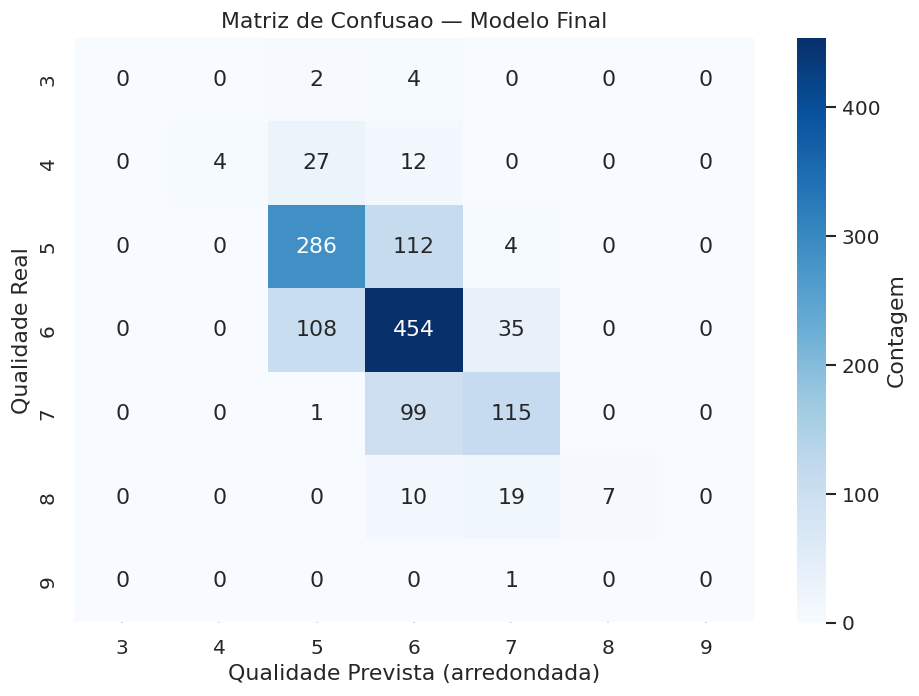

Diagonal = previsoes corretas (nota arredondada = nota real)
Acertos exatos: 866/1300 (66.6%)


In [31]:
# Afonso Carvalho e Marcello Portugal
# Matriz de confusao adaptada para regressao
# Arredondamos as previsoes ao inteiro mais proximo para comparar com as notas reais

y_pred_final = modelo_final.predict(X_test_sc)
y_pred_rounded = np.clip(np.round(y_pred_final), 3, 9).astype(int)

notas = sorted(y_test.unique())

# Construir a matriz manualmente
conf_matrix = pd.crosstab(
    y_test, y_pred_rounded,
    rownames=['Real'], colnames=['Previsto'],
    dropna=False
)
# Preencher notas que possam faltar
for n in notas:
    if n not in conf_matrix.columns:
        conf_matrix[n] = 0
    if n not in conf_matrix.index:
        conf_matrix.loc[n] = 0
conf_matrix = conf_matrix.sort_index(axis=0).sort_index(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            cbar_kws={'label': 'Contagem'}, ax=ax)
ax.set_xlabel('Qualidade Prevista (arredondada)')
ax.set_ylabel('Qualidade Real')
ax.set_title('Matriz de Confusao — Modelo Final')
plt.tight_layout()
plt.savefig('../reports/figures/M3_matriz_confusao.png', bbox_inches='tight')
plt.show()

print('Diagonal = previsoes corretas (nota arredondada = nota real)')
acertos = sum(y_test.values == y_pred_rounded)
print(f'Acertos exatos: {acertos}/{len(y_test)} ({acertos/len(y_test)*100:.1f}%)')

MAE por nota de qualidade:


,MAE,Contagem
Real,,
3,2.5820,6
4,1.2388,43
5,0.3857,402
6,0.3064,597
7,0.5152,215
8,1.1542,36
9,2.3560,1


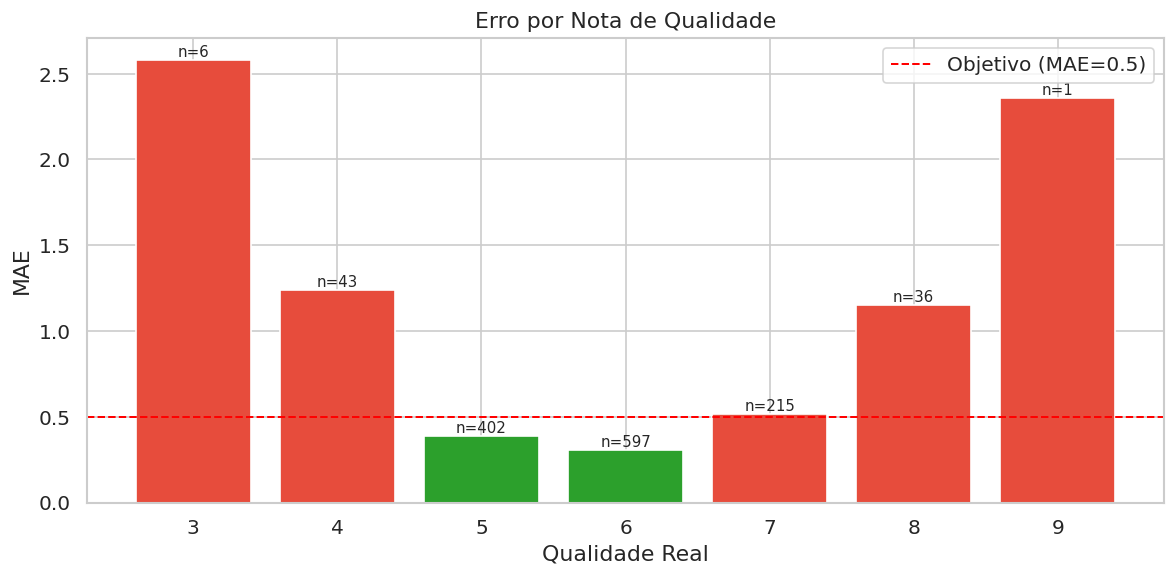

In [32]:
# Afonso Carvalho e Marcello Portugal
# MAE por nota de qualidade — onde o modelo erra mais?

erros_por_nota = pd.DataFrame({
    'Real'     : y_test.values,
    'Previsto' : y_pred_final,
    'Erro Abs' : np.abs(y_test.values - y_pred_final)
})

mae_por_nota = erros_por_nota.groupby('Real').agg(
    MAE=('Erro Abs', 'mean'),
    Contagem=('Erro Abs', 'count')
).round(4)

print('MAE por nota de qualidade:')
display(mae_por_nota)

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#2ca02c' if mae < 0.5 else '#e74c3c' for mae in mae_por_nota['MAE']]
bars = ax.bar(mae_por_nota.index.astype(str), mae_por_nota['MAE'],
              color=cores, edgecolor='white')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='Objetivo (MAE=0.5)')
ax.set_xlabel('Qualidade Real')
ax.set_ylabel('MAE')
ax.set_title('Erro por Nota de Qualidade')

for bar, n in zip(bars, mae_por_nota['Contagem']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'n={n}', ha='center', fontsize=9)

ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/M3_mae_por_nota.png', bbox_inches='tight')
plt.show()

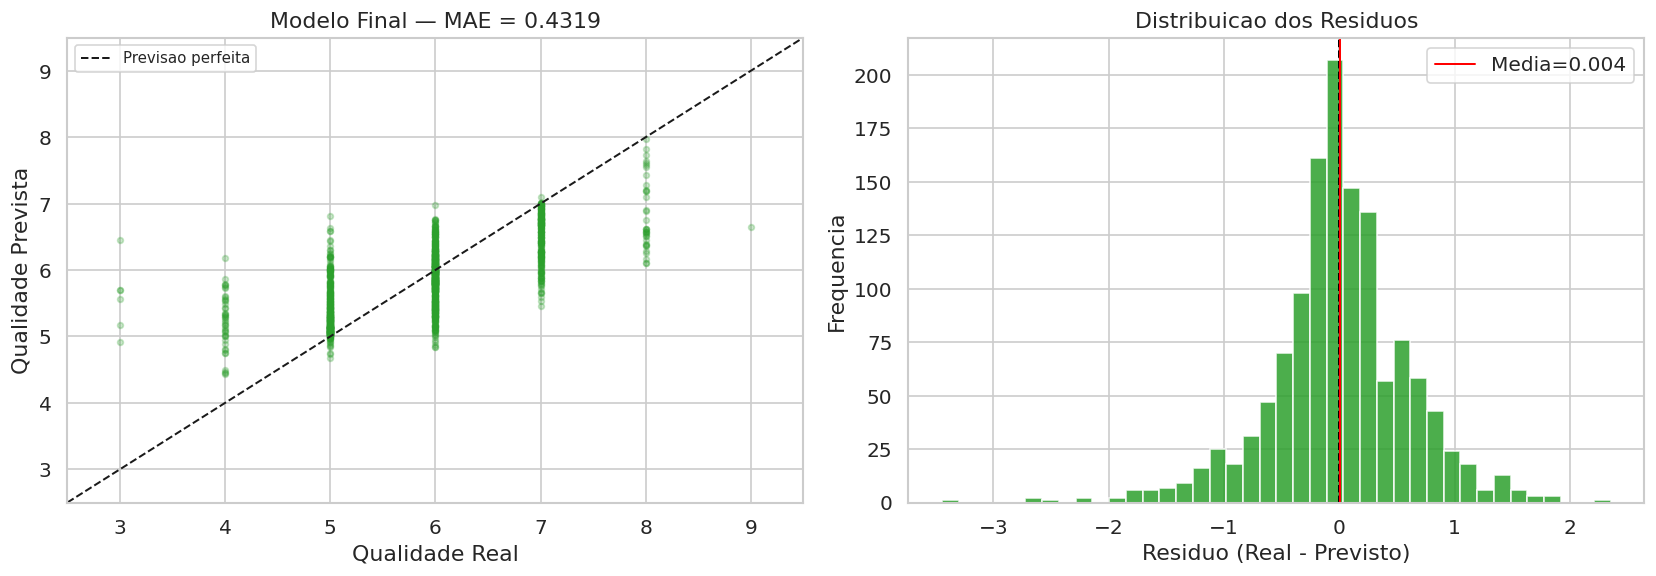

Residuos — Media: 0.0043, Desvio: 0.6003
Residuos maiores que 1 ponto: 133 (10.2%)


In [33]:
# Afonso Carvalho e Marcello Portugal
# Residuos do modelo final: distribuicao e previsoes vs real

residuos = y_test.values - y_pred_final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Previsoes vs real
ax = axes[0]
ax.scatter(y_test, y_pred_final, alpha=0.25, s=12, color='#2ca02c')
lims = [y_test.min() - 0.5, y_test.max() + 0.5]
ax.plot(lims, lims, 'k--', linewidth=1.2, label='Previsao perfeita')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Qualidade Real')
ax.set_ylabel('Qualidade Prevista')
ax.set_title(f'Modelo Final — MAE = {res_final["MAE Teste"]}')
ax.legend(fontsize=9)

# Distribuicao dos residuos
ax = axes[1]
ax.hist(residuos, bins=40, color='#2ca02c', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax.axvline(residuos.mean(), color='red', linestyle='-', linewidth=1.2, label=f'Media={residuos.mean():.3f}')
ax.set_xlabel('Residuo (Real - Previsto)')
ax.set_ylabel('Frequencia')
ax.set_title('Distribuicao dos Residuos')
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/M3_modelo_final_residuos.png', bbox_inches='tight')
plt.show()

print(f'Residuos — Media: {residuos.mean():.4f}, Desvio: {residuos.std():.4f}')
print(f'Residuos maiores que 1 ponto: {(np.abs(residuos) > 1).sum()} ({(np.abs(residuos) > 1).mean()*100:.1f}%)')

In [34]:
# Afonso Carvalho e Marcello Portugal
# Piores previsoes: casos com erro absoluto > 1.5 pontos

df_erros = pd.DataFrame({
    'Real'     : y_test.values,
    'Previsto' : np.round(y_pred_final, 2),
    'Erro'     : np.round(residuos, 2),
    'Erro_Abs' : np.round(np.abs(residuos), 2)
}, index=X_test.index)

piores = df_erros[df_erros['Erro_Abs'] > 1.5].sort_values('Erro_Abs', ascending=False)

print(f'Registos com erro absoluto > 1.5 pontos: {len(piores)}')
if len(piores) > 0:
    display(piores.head(10))
    print('\nCaracteristicas destes vinhos (valores originais):')
    display(X_test.loc[piores.head(10).index].round(3))
else:
    print('Nenhum caso com erro superior a 1.5 pontos.')

Registos com erro absoluto > 1.5 pontos: 34


,Real,Previsto,Erro,Erro_Abs
2339,3,6.45,-3.45,3.45
3649,3,5.70,-2.70,2.70
6344,3,5.69,-2.69,2.69
3016,3,5.56,-2.56,2.56
3204,9,6.64,2.36,2.36
3715,4,6.18,-2.18,2.18
1374,3,5.17,-2.17,2.17
1893,3,4.92,-1.92,1.92
2197,8,6.10,1.90,1.90
1090,8,6.11,1.89,1.89



Caracteristicas destes vinhos (valores originais):


,fixed acidity,citric acid,residual sugar,chlorides,total sulfur dioxide,density,pH,sulphates,alcohol,is_red,so2_ratio,volatile_acidity_ratio
2339,6.90,0.40,4.60,0.022,19.0,0.992,3.31,0.37,12.6,0,0.263,0.057
3649,9.65,0.38,11.10,0.034,123.0,1.000,2.93,0.55,9.7,0,0.122,0.024
6344,6.10,0.25,2.90,0.047,274.5,0.993,3.44,0.64,10.5,0,0.281,0.043
3016,8.60,0.35,15.55,0.057,274.5,1.000,3.04,0.63,11.0,0,0.129,0.064
3204,7.10,0.49,2.20,0.032,113.0,0.990,3.37,0.42,12.9,0,0.274,0.037
3715,6.80,0.27,1.20,0.034,68.0,0.990,3.14,0.37,11.7,0,0.279,0.029
1374,6.80,0.04,1.20,0.106,29.0,0.995,3.32,0.51,9.8,1,0.552,0.096
1893,9.10,0.38,1.60,0.066,182.0,0.997,3.23,0.38,8.5,0,0.187,0.065
2197,5.90,0.29,11.40,0.036,115.0,0.995,3.35,0.48,10.5,0,0.270,0.046
1090,9.65,0.54,1.90,0.083,74.0,0.995,2.98,0.63,11.8,1,0.568,0.027


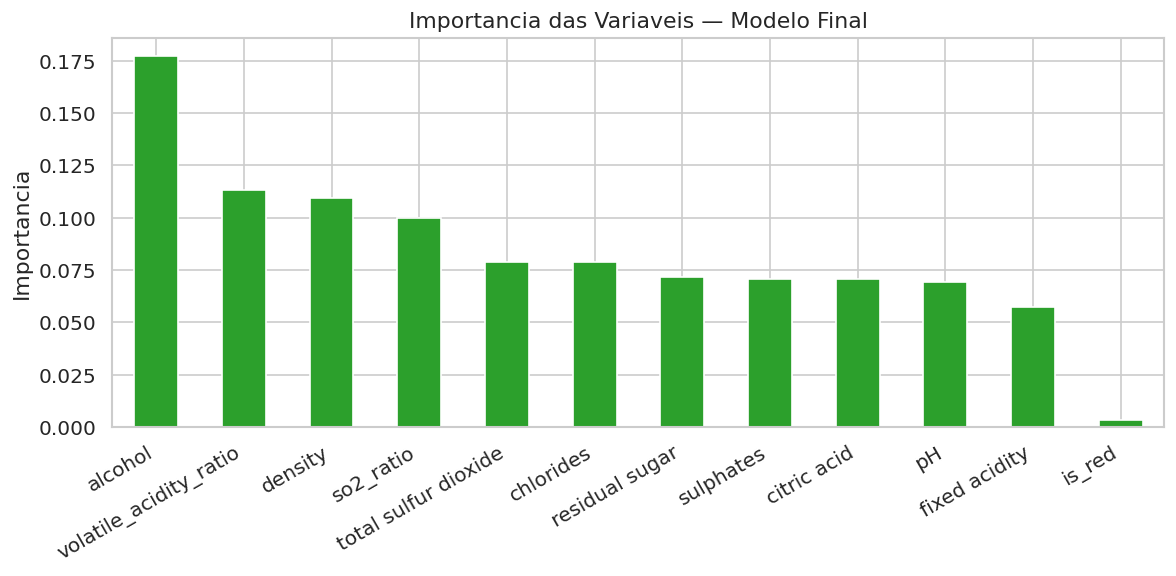

Top 5 variaveis:
  alcohol: 0.1772 (17.7%)
  volatile_acidity_ratio: 0.1133 (11.3%)
  density: 0.1093 (10.9%)
  so2_ratio: 0.0997 (10.0%)
  total sulfur dioxide: 0.0790 (7.9%)


In [35]:
# Afonso Carvalho e Marcello Portugal
# Importancia das variaveis no modelo final (apos tuning)

fi_final = pd.Series(
    modelo_final.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
fi_final.plot(kind='bar', color='#2ca02c', edgecolor='white', ax=ax)
ax.set_title('Importancia das Variaveis — Modelo Final')
ax.set_ylabel('Importancia')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/M3_feature_importance_final.png', bbox_inches='tight')
plt.show()

print('Top 5 variaveis:')
for var, imp in fi_final.head(5).items():
    print(f'  {var}: {imp:.4f} ({imp*100:.1f}%)')

In [36]:
# Afonso Carvalho e Marcello Portugal
# Resumo final do modelo

print('=' * 60)
print('RESUMO FINAL — MODELO DE PREVISAO DE QUALIDADE DE VINHOS')
print('=' * 60)
print(f'Algoritmo      : Random Forest')
print(f'Parametros     : {modelo_final.get_params()}')
print(f'MAE Teste      : {res_final["MAE Teste"]}')
print(f'RMSE Teste     : {res_final["RMSE Teste"]}')
print(f'R2 Teste       : {res_final["R2 Teste"]}')
print(f'MAE CV (5-Fold): {cv_mae.mean():.4f} +/- {cv_mae.std():.4f}')
print(f'Objetivo SMART : MAE < 0.5 — {"ATINGIDO" if res_final["MAE Teste"] < 0.5 else "NAO ATINGIDO"}')
print('=' * 60)

RESUMO FINAL — MODELO DE PREVISAO DE QUALIDADE DE VINHOS
Algoritmo      : Random Forest
Parametros     : {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 382, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
MAE Teste      : 0.4319
RMSE Teste     : 0.6003
R2 Teste       : 0.512
MAE CV (5-Fold): 0.4431 +/- 0.0135
Objetivo SMART : MAE < 0.5 — ATINGIDO
